<a href="https://colab.research.google.com/github/7amzaGH/NeptuNet-AUV-Intelligent-System/blob/main/notebooks/neptunet_framework_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NeptuNet Framework Simulation Demo

This notebook demonstrates the framework-level orchestration logic of **NeptuNet**.

It does **not** perform real image inference, AUV control, SLAM, underwater physics simulation, or robotic deployment.

Instead, it uses simulated module outputs to show how the three NeptuNet perception levels communicate:

1. **Level 1** — Pipeline geometric perception  
2. **Level 2** — Bubble-based early warning  
3. **Level 3** — Conditional leak confirmation  

Each scenario contains **10 inspection windows**, representing approximately **10 seconds** of inspection.

## 1. Clone the NeptuNet Repository

This cell clones the main NeptuNet framework hub and enters the repository.

Expected repository layout:

```text
NeptuNet-AUV-Intelligent-System/
│
├── integration/
│   └── neptunet_orchestrator.py
│
└── scenarios/
    ├── scenario_01_normal_inspection.json
    ├── scenario_02_false_anomaly_return.json
    ├── scenario_03_pipeline_reacquisition.json
    └── scenario_04_confirmed_leak.json
```

In [1]:
!git clone https://github.com/7amzaGH/NeptuNet-AUV-Intelligent-System.git
%cd NeptuNet-AUV-Intelligent-System

Cloning into 'NeptuNet-AUV-Intelligent-System'...
remote: Enumerating objects: 145, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 145 (delta 50), reused 28 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (145/145), 31.46 MiB | 42.22 MiB/s, done.
Resolving deltas: 100% (50/50), done.
/content/NeptuNet-AUV-Intelligent-System


## 2. Import Required Libraries

The notebook uses:

- `json` and `pathlib` for loading scenario files
- `pandas` for tabular analysis
- `matplotlib` for visualization
- `NeptuNetOrchestrator` for framework-level orchestration

In [2]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## 3. Connect Python to the Repository Code

The orchestrator file is located inside:

```text
integration/neptunet_orchestrator.py
```

This cell adds the repository root to `sys.path` so the notebook can import the orchestrator.

In [4]:
REPO_ROOT = Path.cwd()
sys.path.append(str(REPO_ROOT))

print("Repository root:", REPO_ROOT)
print("Integration folder exists:", (REPO_ROOT / "integration").exists())
print("Scenarios folder exists:", (REPO_ROOT / "scenarios").exists())

Repository root: /content/NeptuNet-AUV-Intelligent-System
Integration folder exists: True
Scenarios folder exists: True


## 4. Import the NeptuNet Orchestrator

The orchestrator follows three simple rules:

```text
Level 1 always runs.
Level 2 runs only when the pipeline is detected.
Level 3 runs only when the bubble suspicion score crosses the threshold.
```

In [5]:
from integration.neptunet_orchestrator import NeptuNetOrchestrator

## 5. Load the Simulation Scenarios

Each scenario contains 10 inspection windows.

The JSON fields simulate module outputs:

| JSON field | Meaning |
|---|---|
| `pipeline` | Simulated Level 1 output |
| `bubble` | Simulated Level 2 output |
| `leak` | Simulated Level 3 output |
| `suspicion_score` | Trigger value deciding whether Level 3 activates |

In [6]:
SCENARIO_DIR = REPO_ROOT / "scenarios"

scenario_files = {
    "Scenario 1 — Normal Inspection": SCENARIO_DIR / "scenario_01_normal_inspection.json",
    "Scenario 2 — False Anomaly Return": SCENARIO_DIR / "scenario_02_false_anomaly_return.json",
    "Scenario 3 — Pipeline Reacquisition": SCENARIO_DIR / "scenario_03_pipeline_reacquisition.json",
    "Scenario 4 — Confirmed Leak": SCENARIO_DIR / "scenario_04_confirmed_leak.json",
}

for name, path in scenario_files.items():
    print(f"{name}: {path.exists()} -> {path}")

Scenario 1 — Normal Inspection: True -> /content/NeptuNet-AUV-Intelligent-System/scenarios/scenario_01_normal_inspection.json
Scenario 2 — False Anomaly Return: True -> /content/NeptuNet-AUV-Intelligent-System/scenarios/scenario_02_false_anomaly_return.json
Scenario 3 — Pipeline Reacquisition: True -> /content/NeptuNet-AUV-Intelligent-System/scenarios/scenario_03_pipeline_reacquisition.json
Scenario 4 — Confirmed Leak: True -> /content/NeptuNet-AUV-Intelligent-System/scenarios/scenario_04_confirmed_leak.json


In [7]:
def load_scenario(path: Path):
    """Load one NeptuNet JSON scenario."""
    if not path.exists():
        raise FileNotFoundError(f"Scenario file not found: {path}")

    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


scenarios = {
    name: load_scenario(path)
    for name, path in scenario_files.items()
}

print("Loaded scenarios:")
for name, scenario in scenarios.items():
    print(f"- {name}: {len(scenario)} inspection windows")

Loaded scenarios:
- Scenario 1 — Normal Inspection: 10 inspection windows
- Scenario 2 — False Anomaly Return: 10 inspection windows
- Scenario 3 — Pipeline Reacquisition: 10 inspection windows
- Scenario 4 — Confirmed Leak: 10 inspection windows


## 6. Run the NeptuNet Orchestrator

The suspicion threshold controls when Level 3 leak confirmation is activated.

In this demo:

```text
Level 3 activates when suspicion_score >= 0.70
```

In [8]:
SUSPICION_THRESHOLD = 0.70

orchestrator = NeptuNetOrchestrator(
    suspicion_threshold=SUSPICION_THRESHOLD
)

all_decisions = {}

for scenario_name, scenario_data in scenarios.items():
    print("#" * 90)
    print(scenario_name)
    print("#" * 90)

    decisions = orchestrator.run_scenario(scenario_data)
    all_decisions[scenario_name] = decisions

##########################################################################################
Scenario 1 — Normal Inspection
##########################################################################################
[Window 01] System State: NORMAL_MONITORING
[Level 1] ACTIVE  | Pipeline detected | center_offset=-5.2 px | orientation=1.2° | direction=STRAIGHT
[Level 2] ACTIVE  | Bubble monitoring | activity=True | suspicion_score=0.08
[Level 3] INACTIVE | Suspicion threshold not reached

[Window 02] System State: NORMAL_MONITORING
[Level 1] ACTIVE  | Pipeline detected | center_offset=-4.7 px | orientation=1.5° | direction=STRAIGHT
[Level 2] ACTIVE  | Bubble monitoring | activity=True | suspicion_score=0.10
[Level 3] INACTIVE | Suspicion threshold not reached

[Window 03] System State: NORMAL_MONITORING
[Level 1] ACTIVE  | Pipeline detected | center_offset=-6.0 px | orientation=2.1° | direction=STRAIGHT
[Level 2] ACTIVE  | Bubble monitoring | activity=True | suspicion_score=0.12
[Level 3] 

## 7. Convert Decisions to Tables

The orchestrator returns decision objects. This cell converts them into pandas DataFrames for analysis and visualization.

In [9]:
def decisions_to_dataframe(decisions):
    """Convert NeptuNetDecision objects into a pandas DataFrame."""
    rows = []

    for decision in decisions:
        rows.append({
            "window": decision.frame_id,
            "system_state": decision.system_state,
            "level1_active": decision.pipeline.active,
            "pipeline_detected": decision.pipeline.detected,
            "center_offset_px": decision.pipeline.center_offset_px,
            "orientation_deg": decision.pipeline.orientation_deg,
            "pipeline_direction": decision.pipeline.direction,
            "level2_active": decision.bubble.active,
            "bubble_activity": decision.bubble.activity_detected,
            "suspicion_score": decision.bubble.suspicion_score,
            "level3_active": decision.leak.active,
            "plume_detected": decision.leak.plume_detected,
            "plume_centroid": decision.leak.plume_centroid,
            "probable_source": decision.leak.probable_source,
            "propagation_direction": decision.leak.propagation_direction,
        })

    return pd.DataFrame(rows)


scenario_tables = {
    name: decisions_to_dataframe(decisions)
    for name, decisions in all_decisions.items()
}

## 8. Inspect One Scenario Table

The confirmed leak scenario shows the full NeptuNet path:

```text
Pipeline detected → Bubble suspicion increases → Level 3 activates → Leak confirmed
```

In [10]:
scenario_tables["Scenario 4 — Confirmed Leak"]

,window,system_state,level1_active,pipeline_detected,center_offset_px,orientation_deg,pipeline_direction,level2_active,bubble_activity,suspicion_score,level3_active,plume_detected,plume_centroid,probable_source,propagation_direction
0,1,NORMAL_MONITORING,True,True,-4.0,1.1,STRAIGHT,True,True,0.10,False,False,None,None,None
1,2,NORMAL_MONITORING,True,True,-5.1,1.8,STRAIGHT,True,True,0.21,False,False,None,None,None
2,3,NORMAL_MONITORING,True,True,-8.2,3.0,RIGHT,True,True,0.44,False,False,None,None,None
3,4,NORMAL_MONITORING,True,True,-10.4,4.2,RIGHT,True,True,0.67,False,False,None,None,None
4,5,LEAK_CONFIRMED,True,True,-13.5,5.3,RIGHT,True,True,0.78,True,True,"[325, 270]","[318, 440]",UP
5,6,LEAK_CONFIRMED,True,True,-15.0,5.8,RIGHT,True,True,0.84,True,True,"[326, 268]","[318, 439]",UP-RIGHT
6,7,LEAK_CONFIRMED,True,True,-14.0,5.2,RIGHT,True,True,0.89,True,True,"[327, 266]","[318, 438]",UP-RIGHT
7,8,LEAK_CONFIRMED,True,True,-11.0,4.0,STRAIGHT,True,True,0.92,True,True,"[328, 264]","[318, 438]",UP-RIGHT
8,9,LEAK_CONFIRMED,True,True,-9.0,3.1,STRAIGHT,True,True,0.94,True,True,"[329, 263]","[318, 437]",UP-RIGHT
9,10,LEAK_CONFIRMED,True,True,-7.0,2.0,STRAIGHT,True,True,0.95,True,True,"[330, 262]","[318, 437]",UP-RIGHT


## 9. Scenario Summary

This table summarizes how many windows were spent in each system state.

In [11]:
summary_rows = []

for scenario_name, df in scenario_tables.items():
    state_counts = df["system_state"].value_counts().to_dict()

    summary_rows.append({
        "scenario": scenario_name,
        "normal_monitoring": state_counts.get("NORMAL_MONITORING", 0),
        "pipeline_search": state_counts.get("PIPELINE_SEARCH", 0),
        "suspicion_unconfirmed": state_counts.get("SUSPICION_UNCONFIRMED", 0),
        "leak_confirmed": state_counts.get("LEAK_CONFIRMED", 0),
        "level3_active_windows": int(df["level3_active"].sum()),
        "max_suspicion_score": df["suspicion_score"].max(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,scenario,normal_monitoring,pipeline_search,suspicion_unconfirmed,leak_confirmed,level3_active_windows,max_suspicion_score
0,Scenario 1 — Normal Inspection,10,0,0,0,0,0.18
1,Scenario 2 — False Anomaly Return,8,0,2,0,2,0.81
2,Scenario 3 — Pipeline Reacquisition,7,3,0,0,0,0.18
3,Scenario 4 — Confirmed Leak,4,0,0,6,6,0.95


## 10. Plot Bubble Suspicion Score

This plot shows how Level 2 suspicion evolves over 10 inspection windows.

The dashed line is the Level 3 activation threshold.

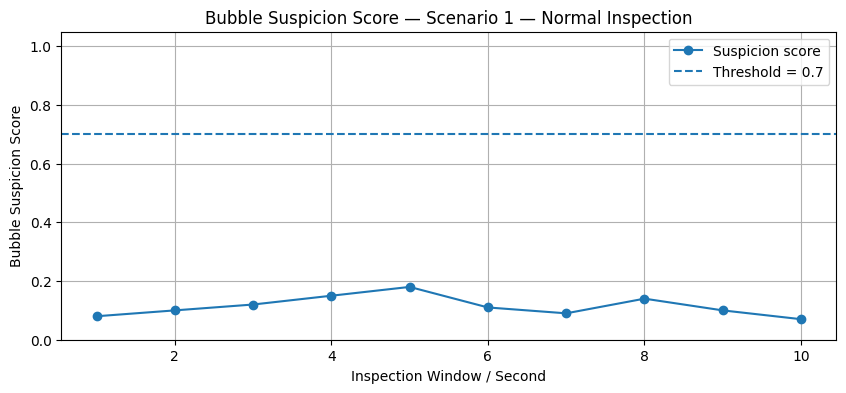

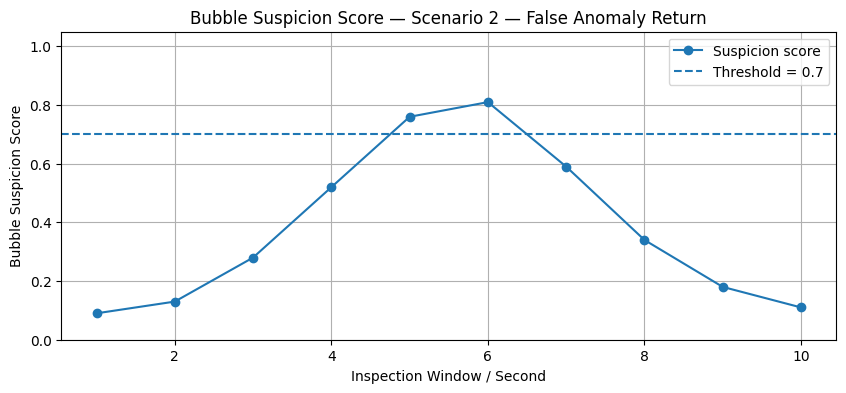

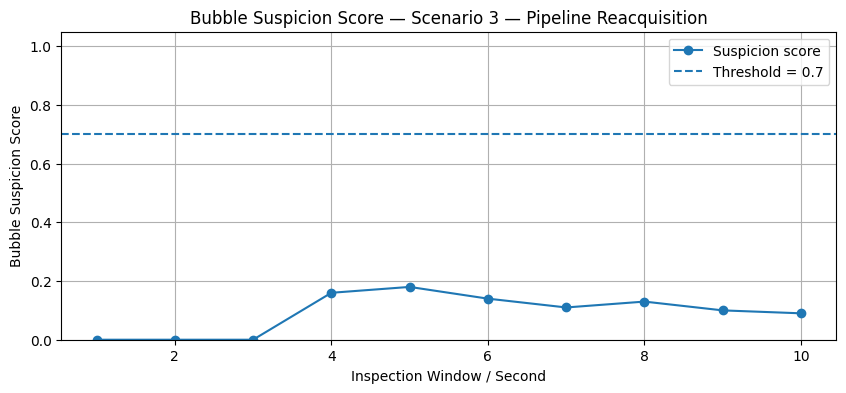

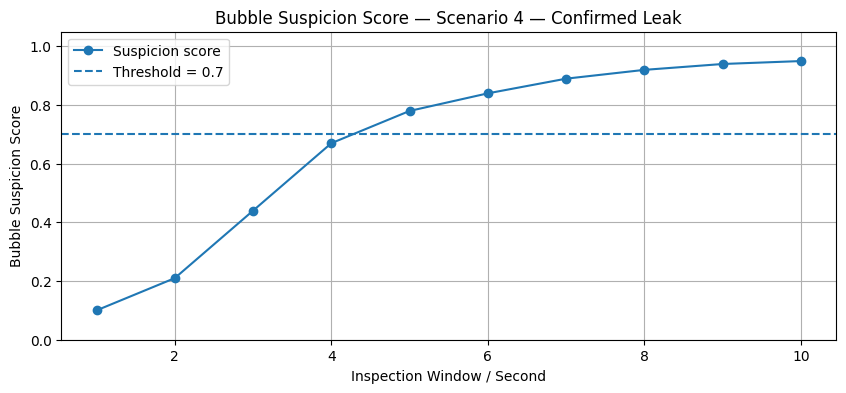

In [12]:
def plot_suspicion_score(df, title, threshold=0.70):
    plt.figure(figsize=(10, 4))
    plt.plot(df["window"], df["suspicion_score"], marker="o", label="Suspicion score")
    plt.axhline(threshold, linestyle="--", label=f"Threshold = {threshold}")
    plt.title(title)
    plt.xlabel("Inspection Window / Second")
    plt.ylabel("Bubble Suspicion Score")
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.legend()
    plt.show()


for scenario_name, df in scenario_tables.items():
    plot_suspicion_score(df, f"Bubble Suspicion Score — {scenario_name}", SUSPICION_THRESHOLD)

## 11. Plot Module Activation Timeline

This plot shows which NeptuNet modules are active during each inspection window.

Expected behavior:

- **Level 1** is always active.
- **Level 2** activates only when the pipeline is detected.
- **Level 3** activates only when suspicion crosses the threshold.

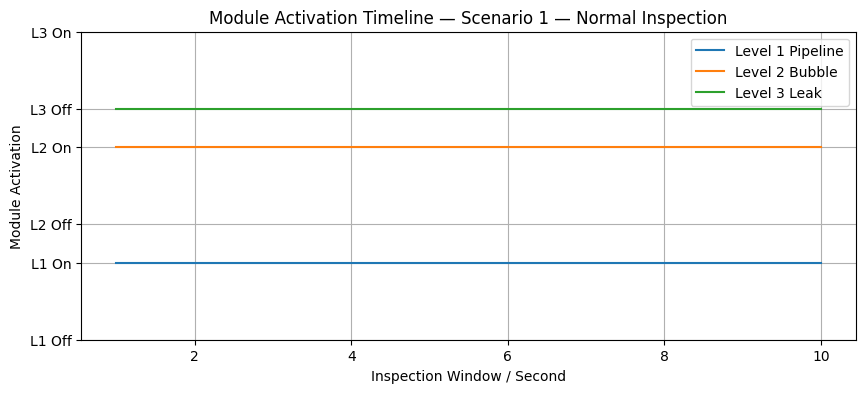

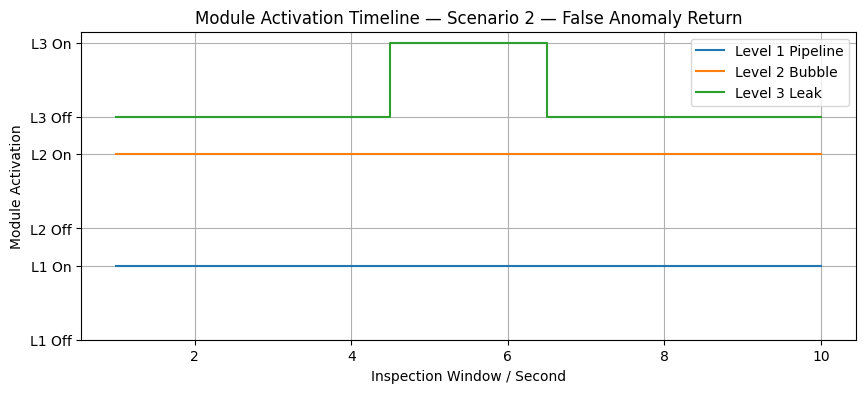

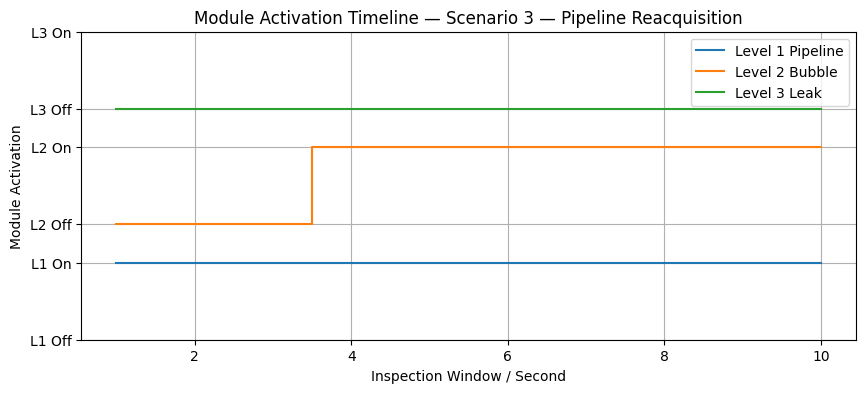

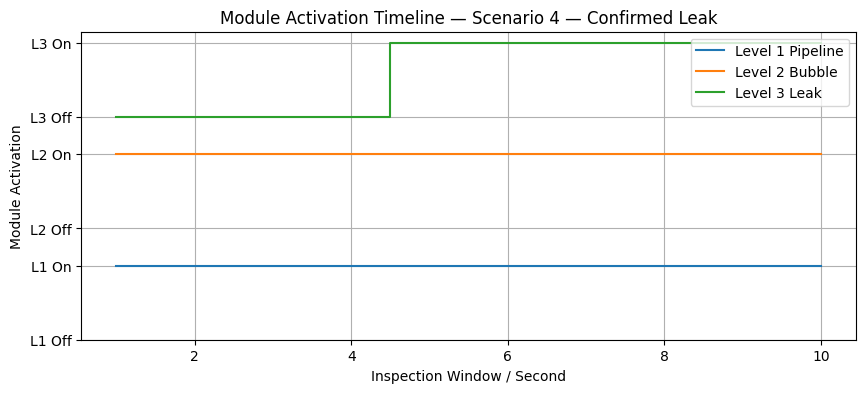

In [13]:
def plot_module_activation(df, title):
    plt.figure(figsize=(10, 4))
    plt.step(df["window"], df["level1_active"].astype(int) + 0.0, where="mid", label="Level 1 Pipeline")
    plt.step(df["window"], df["level2_active"].astype(int) + 1.5, where="mid", label="Level 2 Bubble")
    plt.step(df["window"], df["level3_active"].astype(int) + 3.0, where="mid", label="Level 3 Leak")
    plt.yticks([0, 1, 1.5, 2.5, 3.0, 4.0], ["L1 Off", "L1 On", "L2 Off", "L2 On", "L3 Off", "L3 On"])
    plt.title(title)
    plt.xlabel("Inspection Window / Second")
    plt.ylabel("Module Activation")
    plt.grid(True)
    plt.legend(loc="upper right")
    plt.show()


for scenario_name, df in scenario_tables.items():
    plot_module_activation(df, f"Module Activation Timeline — {scenario_name}")

## 12. Plot System State Timeline

System states are encoded as numeric values only for visualization.

```text
0 = PIPELINE_SEARCH
1 = NORMAL_MONITORING
2 = SUSPICION_UNCONFIRMED
3 = LEAK_CONFIRMED
```

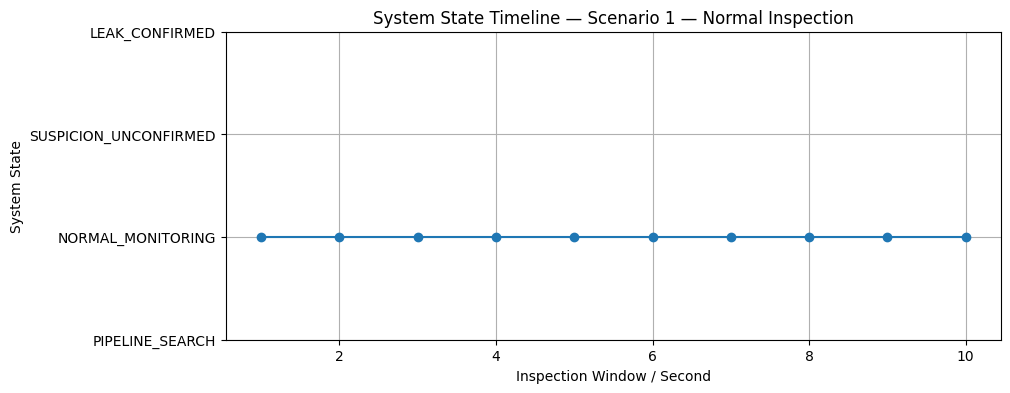

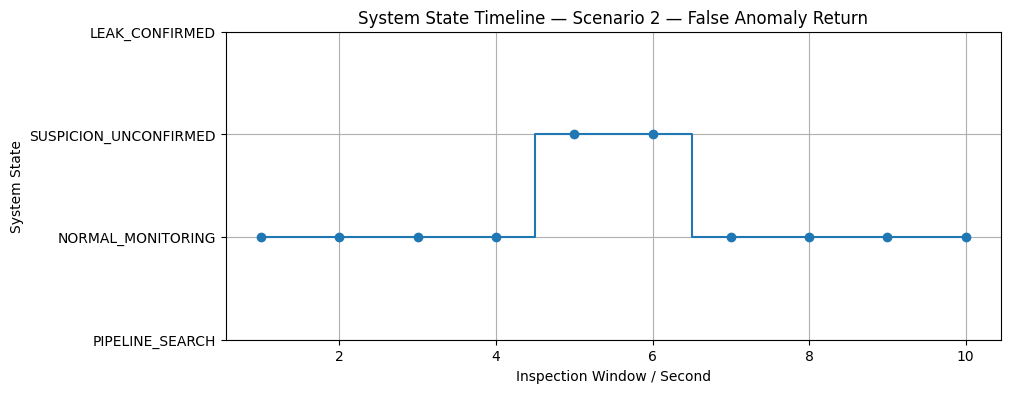

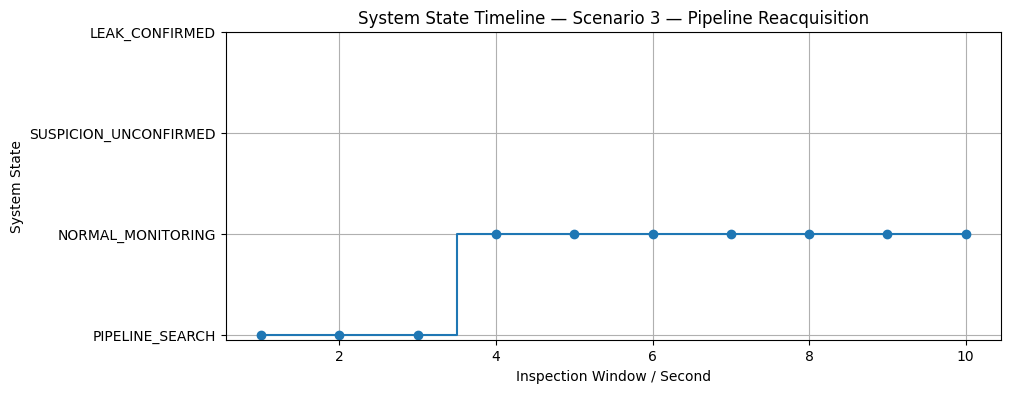

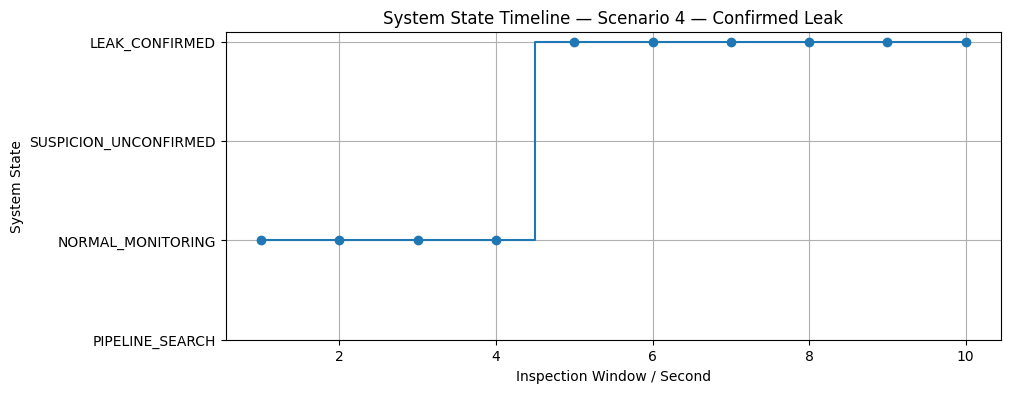

In [14]:
STATE_ENCODING = {
    "PIPELINE_SEARCH": 0,
    "NORMAL_MONITORING": 1,
    "SUSPICION_UNCONFIRMED": 2,
    "LEAK_CONFIRMED": 3,
}


def plot_system_state(df, title):
    encoded_states = df["system_state"].map(STATE_ENCODING)
    plt.figure(figsize=(10, 4))
    plt.step(df["window"], encoded_states, where="mid", marker="o")
    plt.yticks(list(STATE_ENCODING.values()), list(STATE_ENCODING.keys()))
    plt.title(title)
    plt.xlabel("Inspection Window / Second")
    plt.ylabel("System State")
    plt.grid(True)
    plt.show()


for scenario_name, df in scenario_tables.items():
    plot_system_state(df, f"System State Timeline — {scenario_name}")

## 13. Scenario-Level Interpretation

The four scenarios demonstrate the main operating modes of the NeptuNet framework:

| Scenario | What it demonstrates |
|---|---|
| Scenario 1 | Stable normal inspection |
| Scenario 2 | False anomaly handling and return to monitoring |
| Scenario 3 | Pipeline loss and reacquisition |
| Scenario 4 | Confirmed leak event |

In [15]:
for scenario_name, df in scenario_tables.items():
    print("=" * 90)
    print(scenario_name)
    print("=" * 90)
    print("System states:")
    print(df["system_state"].value_counts())
    print("Level 3 activated windows:")
    active_windows = df[df["level3_active"]]["window"].tolist()
    print(active_windows if active_windows else "None")
    print("Maximum suspicion score:")
    print(df["suspicion_score"].max())
    print()

Scenario 1 — Normal Inspection
System states:
system_state
NORMAL_MONITORING    10
Name: count, dtype: int64
Level 3 activated windows:
None
Maximum suspicion score:
0.18

Scenario 2 — False Anomaly Return
System states:
system_state
NORMAL_MONITORING        8
SUSPICION_UNCONFIRMED    2
Name: count, dtype: int64
Level 3 activated windows:
[5, 6]
Maximum suspicion score:
0.81

Scenario 3 — Pipeline Reacquisition
System states:
system_state
NORMAL_MONITORING    7
PIPELINE_SEARCH      3
Name: count, dtype: int64
Level 3 activated windows:
None
Maximum suspicion score:
0.18

Scenario 4 — Confirmed Leak
System states:
system_state
LEAK_CONFIRMED       6
NORMAL_MONITORING    4
Name: count, dtype: int64
Level 3 activated windows:
[5, 6, 7, 8, 9, 10]
Maximum suspicion score:
0.95



## 14. Save Simulation Outputs

The scenario outputs are saved as CSV files for documentation or later analysis.

In [17]:
OUTPUT_DIR = REPO_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

for scenario_name, df in scenario_tables.items():
    safe_name = scenario_name.lower().replace(" ", "_").replace("—", "").replace("__", "_")
    output_path = OUTPUT_DIR / f"{safe_name}.csv"
    df.to_csv(output_path, index=False)
    print("Saved:", output_path)

Saved: /content/outputs/scenario_1_normal_inspection.csv
Saved: /content/outputs/scenario_2_false_anomaly_return.csv
Saved: /content/outputs/scenario_3_pipeline_reacquisition.csv
Saved: /content/outputs/scenario_4_confirmed_leak.csv


## 15. Final Notes

This notebook demonstrates NeptuNet as a **framework-level orchestration simulation**.

It shows that:

1. Pipeline perception provides continuous infrastructure context.
2. Bubble monitoring acts as a lightweight early-warning layer.
3. Leak confirmation is activated conditionally.
4. The framework can represent normal inspection, false anomaly handling, pipeline reacquisition, and confirmed leak events.

This simulation is intentionally limited to perception-level coordination and does not claim full underwater robotic autonomy.